In [18]:
from pathlib import Path
import time
import joblib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.svm import LinearSVC
from sklearn.linear_model import SGDClassifier

from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

print("Model training environment ready ✅")

Model training environment ready ✅


In [3]:
FEATURES_DIR = Path("../data/features")

# Load training features
X_train = np.load(
    FEATURES_DIR / "X_train_hog.npy",
    mmap_mode="r"
)

# Labels contain strings, so allow_pickle=True
y_train = np.load(
    FEATURES_DIR / "y_train_hog.npy",
    allow_pickle=True
)

# Load validation features
X_val = np.load(
    FEATURES_DIR / "X_val_hog.npy",
    mmap_mode="r"
)

y_val = np.load(
    FEATURES_DIR / "y_val_hog.npy",
    allow_pickle=True
)

print("Training features:", X_train.shape)
print("Training labels:", y_train.shape)

print()

print("Validation features:", X_val.shape)
print("Validation labels:", y_val.shape)

print()

print("Training dtype:", X_train.dtype)
print("Validation dtype:", X_val.dtype)
print("Label dtype:", y_train.dtype)

print("\nHOG datasets loaded successfully ✅")

Training features: (14500, 8100)
Training labels: (14500,)

Validation features: (8700, 8100)
Validation labels: (8700,)

Training dtype: float32
Validation dtype: float32
Label dtype: object

HOG datasets loaded successfully ✅


In [4]:
# Encode class labels into numeric values

label_encoder = LabelEncoder()

y_train_encoded = label_encoder.fit_transform(y_train)
y_val_encoded = label_encoder.transform(y_val)

print("Number of classes:", len(label_encoder.classes_))
print("Classes:")
print(label_encoder.classes_)

print("\nExample mappings:")

for i, class_name in enumerate(label_encoder.classes_):
    print(f"{class_name:10s} -> {i}")

print("\nEncoded training labels shape:", y_train_encoded.shape)
print("Encoded validation labels shape:", y_val_encoded.shape)

print("\nLabel encoding completed ✅")

Number of classes: 29
Classes:
['A' 'B' 'C' 'D' 'E' 'F' 'G' 'H' 'I' 'J' 'K' 'L' 'M' 'N' 'O' 'P' 'Q' 'R'
 'S' 'T' 'U' 'V' 'W' 'X' 'Y' 'Z' 'del' 'nothing' 'space']

Example mappings:
A          -> 0
B          -> 1
C          -> 2
D          -> 3
E          -> 4
F          -> 5
G          -> 6
H          -> 7
I          -> 8
J          -> 9
K          -> 10
L          -> 11
M          -> 12
N          -> 13
O          -> 14
P          -> 15
Q          -> 16
R          -> 17
S          -> 18
T          -> 19
U          -> 20
V          -> 21
W          -> 22
X          -> 23
Y          -> 24
Z          -> 25
del        -> 26
nothing    -> 27
space      -> 28

Encoded training labels shape: (14500,)
Encoded validation labels shape: (8700,)

Label encoding completed ✅


In [5]:
# Verify encoded training class distribution

unique_classes, class_counts = np.unique(
    y_train_encoded,
    return_counts=True
)

print("Class ID -> Training samples")

for class_id, count in zip(unique_classes, class_counts):
    class_name = label_encoder.inverse_transform([class_id])[0]
    print(f"{class_id:2d} ({class_name:8s}) -> {count}")

print("\nTraining data is ready for ML ✅")

Class ID -> Training samples
 0 (A       ) -> 500
 1 (B       ) -> 500
 2 (C       ) -> 500
 3 (D       ) -> 500
 4 (E       ) -> 500
 5 (F       ) -> 500
 6 (G       ) -> 500
 7 (H       ) -> 500
 8 (I       ) -> 500
 9 (J       ) -> 500
10 (K       ) -> 500
11 (L       ) -> 500
12 (M       ) -> 500
13 (N       ) -> 500
14 (O       ) -> 500
15 (P       ) -> 500
16 (Q       ) -> 500
17 (R       ) -> 500
18 (S       ) -> 500
19 (T       ) -> 500
20 (U       ) -> 500
21 (V       ) -> 500
22 (W       ) -> 500
23 (X       ) -> 500
24 (Y       ) -> 500
25 (Z       ) -> 500
26 (del     ) -> 500
27 (nothing ) -> 500
28 (space   ) -> 500

Training data is ready for ML ✅


In [7]:
# Train first baseline model: Linear SVM

svm_model = LinearSVC(
    C=1.0,
    max_iter=5000,
    random_state=42
)

start_time = time.time()

svm_model.fit(
    X_train,
    y_train_encoded
)

training_time = time.time() - start_time

print("Linear SVM training completed ✅")
print("Training time:", round(training_time, 2), "seconds")

Linear SVM training completed ✅
Training time: 431.02 seconds


In [8]:
# Predict validation dataset

start_time = time.time()

y_val_pred = svm_model.predict(X_val)

prediction_time = time.time() - start_time

print("Validation prediction completed ✅")
print("Predictions:", y_val_pred.shape)
print("Prediction time:", round(prediction_time, 2), "seconds")

Validation prediction completed ✅
Predictions: (8700,)
Prediction time: 0.6 seconds


In [9]:
# Calculate validation accuracy

val_accuracy = accuracy_score(
    y_val_encoded,
    y_val_pred
)

print("Validation Accuracy:", round(val_accuracy, 4))
print(
    "Validation Accuracy (%):",
    round(val_accuracy * 100, 2),
    "%"
)

Validation Accuracy: 0.9114
Validation Accuracy (%): 91.14 %


In [10]:
# Detailed classification report

report = classification_report(
    y_val_encoded,
    y_val_pred,
    target_names=label_encoder.classes_,
    digits=4
)

print("CLASSIFICATION REPORT")
print("=" * 70)
print(report)

CLASSIFICATION REPORT
              precision    recall  f1-score   support

           A     0.8549    0.9033    0.8784       300
           B     0.9178    0.8933    0.9054       300
           C     0.9701    0.9733    0.9717       300
           D     0.8797    0.9267    0.9026       300
           E     0.8855    0.8767    0.8811       300
           F     0.9680    0.9067    0.9363       300
           G     0.9661    0.9500    0.9580       300
           H     0.9799    0.9767    0.9783       300
           I     0.9410    0.9033    0.9218       300
           J     0.9450    0.9733    0.9589       300
           K     0.9349    0.9100    0.9223       300
           L     0.9674    0.9900    0.9786       300
           M     0.8900    0.9167    0.9031       300
           N     0.9472    0.8967    0.9212       300
           O     0.9197    0.9167    0.9182       300
           P     0.9704    0.9833    0.9768       300
           Q     0.9766    0.9733    0.9750       300
     

In [11]:
# Convert classification report to DataFrame

report_dict = classification_report(
    y_val_encoded,
    y_val_pred,
    target_names=label_encoder.classes_,
    output_dict=True
)

report_df = pd.DataFrame(report_dict).transpose()

class_results = report_df.loc[label_encoder.classes_].copy()

class_results = class_results.sort_values(
    by="f1-score",
    ascending=False
)

print("Top 5 best recognized signs:")
display(
    class_results[
        ["precision", "recall", "f1-score", "support"]
    ].head(5)
)

print("\nTop 5 most difficult signs:")
display(
    class_results[
        ["precision", "recall", "f1-score", "support"]
    ].tail(5)
)

Top 5 best recognized signs:


,precision,recall,f1-score,support
nothing,1.000000,1.000000,1.000000,300.0
L,0.967427,0.990000,0.978583,300.0
H,0.979933,0.976667,0.978297,300.0
P,0.970395,0.983333,0.976821,300.0
Q,0.976589,0.973333,0.974958,300.0



Top 5 most difficult signs:


,precision,recall,f1-score,support
S,0.869863,0.846667,0.858108,300.0
R,0.819672,0.833333,0.826446,300.0
W,0.797342,0.800000,0.798669,300.0
U,0.780328,0.793333,0.786777,300.0
V,0.728758,0.743333,0.735974,300.0


In [12]:
# Generate confusion matrix

cm = confusion_matrix(
    y_val_encoded,
    y_val_pred
)

print("Confusion matrix shape:", cm.shape)
print("Total predictions:", cm.sum())
print("Correct predictions:", np.trace(cm))
print("Incorrect predictions:", cm.sum() - np.trace(cm))

Confusion matrix shape: (29, 29)
Total predictions: 8700
Correct predictions: 7929
Incorrect predictions: 771


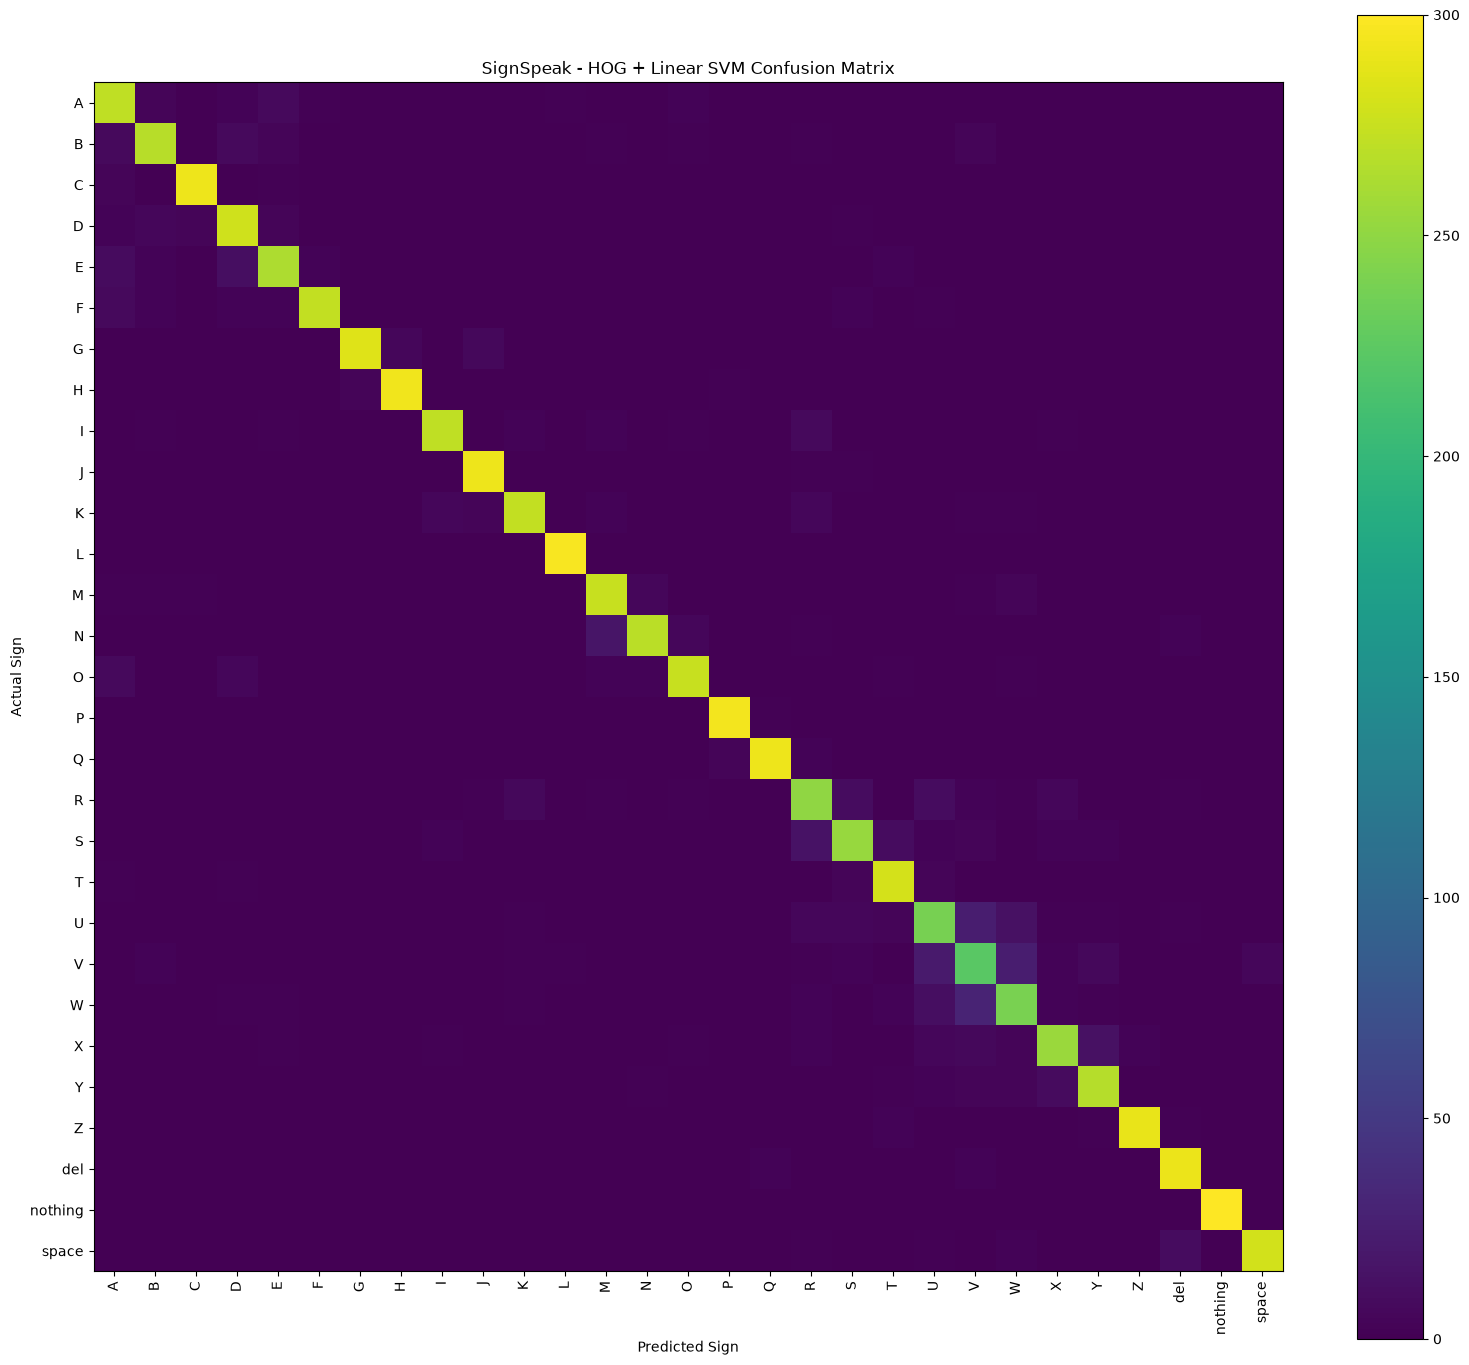

In [13]:
# Visualize confusion matrix

fig, ax = plt.subplots(figsize=(16, 14))

im = ax.imshow(cm)

ax.set_xticks(
    np.arange(len(label_encoder.classes_))
)

ax.set_yticks(
    np.arange(len(label_encoder.classes_))
)

ax.set_xticklabels(
    label_encoder.classes_,
    rotation=90
)

ax.set_yticklabels(
    label_encoder.classes_
)

ax.set_xlabel("Predicted Sign")
ax.set_ylabel("Actual Sign")

ax.set_title(
    "SignSpeak - HOG + Linear SVM Confusion Matrix"
)

fig.colorbar(im, ax=ax)

plt.tight_layout()
plt.show()

In [14]:
# Find most common sign confusions

confusions = []

for actual in range(len(label_encoder.classes_)):
    for predicted in range(len(label_encoder.classes_)):

        if actual != predicted and cm[actual, predicted] > 0:

            confusions.append({
                "Actual": label_encoder.classes_[actual],
                "Predicted": label_encoder.classes_[predicted],
                "Count": cm[actual, predicted]
            })

confusion_df = pd.DataFrame(confusions)

confusion_df = confusion_df.sort_values(
    "Count",
    ascending=False
).reset_index(drop=True)

print("Top 15 most common prediction mistakes:")

display(confusion_df.head(15))

Top 15 most common prediction mistakes:


,Actual,Predicted,Count
0,W,V,30
1,V,W,24
2,U,V,24
3,V,U,22
4,N,M,17
5,S,R,15
6,X,Y,14
7,U,W,13
8,E,D,11
9,W,U,11


In [15]:
MODEL_DIR = Path("../models/trained")
MODEL_DIR.mkdir(parents=True, exist_ok=True)

print("Model directory ready:", MODEL_DIR)

Model directory ready: ../models/trained


In [16]:
# Save trained Linear SVM model

joblib.dump(
    svm_model,
    MODEL_DIR / "hog_linear_svm.joblib"
)

joblib.dump(
    label_encoder,
    MODEL_DIR / "label_encoder.joblib"
)

print("Linear SVM model saved ✅")
print("Label encoder saved ✅")

Linear SVM model saved ✅
Label encoder saved ✅


In [17]:
for file in MODEL_DIR.iterdir():
    print(
        file.name,
        "-",
        round(file.stat().st_size / (1024 ** 2), 2),
        "MB"
    )

hog_linear_svm.joblib - 1.79 MB
label_encoder.joblib - 0.0 MB


In [19]:
# Model 2: SGD Classifier

sgd_model = SGDClassifier(
    loss="hinge",
    max_iter=1000,
    tol=1e-3,
    random_state=42,
    n_jobs=-1
)

start_time = time.time()

sgd_model.fit(
    X_train,
    y_train_encoded
)

sgd_training_time = time.time() - start_time

print("SGD Classifier training completed ✅")
print("Training time:", round(sgd_training_time, 2), "seconds")

SGD Classifier training completed ✅
Training time: 12.64 seconds


In [20]:
# Predict validation data using SGD model

start_time = time.time()

y_val_pred_sgd = sgd_model.predict(X_val)

sgd_prediction_time = time.time() - start_time

print("SGD validation prediction completed ✅")
print("Predictions:", y_val_pred_sgd.shape)
print(
    "Prediction time:",
    round(sgd_prediction_time, 2),
    "seconds"
)

SGD validation prediction completed ✅
Predictions: (8700,)
Prediction time: 0.03 seconds


In [21]:
# Calculate SGD validation accuracy

sgd_accuracy = accuracy_score(
    y_val_encoded,
    y_val_pred_sgd
)

print("SGD Validation Accuracy:", round(sgd_accuracy, 4))
print(
    "SGD Validation Accuracy (%):",
    round(sgd_accuracy * 100, 2),
    "%"
)

SGD Validation Accuracy: 0.8895
SGD Validation Accuracy (%): 88.95 %


In [22]:
# Save SGD model for comparison

joblib.dump(
    sgd_model,
    MODEL_DIR / "hog_sgd_classifier.joblib"
)

print("SGD model saved successfully ✅")

SGD model saved successfully ✅


In [23]:
# Compare trained models

comparison_df = pd.DataFrame({
    "Model": [
        "Linear SVM",
        "SGD Classifier"
    ],
    "Accuracy (%)": [
        round(val_accuracy * 100, 2),
        round(sgd_accuracy * 100, 2)
    ],
    "Training Time (s)": [
        round(training_time, 2),
        round(sgd_training_time, 2)
    ],
    "Prediction Time (s)": [
        round(prediction_time, 2),
        round(sgd_prediction_time, 2)
    ]
})

comparison_df

,Model,Accuracy (%),Training Time (s),Prediction Time (s)
0,Linear SVM,91.14,431.02,0.60
1,SGD Classifier,88.95,12.64,0.03


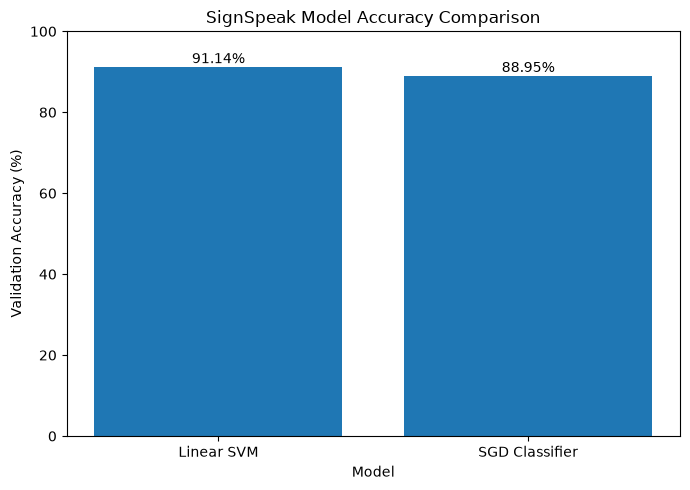

In [24]:
# Compare model accuracy

plt.figure(figsize=(7, 5))

plt.bar(
    comparison_df["Model"],
    comparison_df["Accuracy (%)"]
)

plt.ylabel("Validation Accuracy (%)")
plt.xlabel("Model")
plt.title("SignSpeak Model Accuracy Comparison")

plt.ylim(0, 100)

for i, value in enumerate(comparison_df["Accuracy (%)"]):
    plt.text(
        i,
        value + 1,
        f"{value}%",
        ha="center"
    )

plt.tight_layout()
plt.show()

In [25]:
# Load test HOG features

X_test = np.load(
    FEATURES_DIR / "X_test_hog.npy",
    mmap_mode="r"
)

y_test = np.load(
    FEATURES_DIR / "y_test_hog.npy",
    allow_pickle=True
)

print("Test features:", X_test.shape)
print("Test labels:", y_test.shape)
print("Feature dtype:", X_test.dtype)

print("\nTest dataset loaded successfully ✅")

Test features: (8700, 8100)
Test labels: (8700,)
Feature dtype: float32

Test dataset loaded successfully ✅


In [26]:
# Encode test labels using the SAME encoder

y_test_encoded = label_encoder.transform(y_test)

print("Encoded test labels:", y_test_encoded.shape)
print("Number of unique classes:", len(np.unique(y_test_encoded)))

print("\nTest labels encoded successfully ✅")

Encoded test labels: (8700,)
Number of unique classes: 29

Test labels encoded successfully ✅


In [27]:
# Final evaluation using selected Linear SVM model

start_time = time.time()

y_test_pred = svm_model.predict(X_test)

test_prediction_time = time.time() - start_time

print("Test prediction completed ✅")
print("Predictions:", y_test_pred.shape)
print(
    "Prediction time:",
    round(test_prediction_time, 2),
    "seconds"
)

Test prediction completed ✅
Predictions: (8700,)
Prediction time: 0.75 seconds


In [28]:
# Final test accuracy

test_accuracy = accuracy_score(
    y_test_encoded,
    y_test_pred
)

correct_predictions = np.sum(
    y_test_encoded == y_test_pred
)

incorrect_predictions = len(y_test_encoded) - correct_predictions

print("=" * 50)
print("SIGNSPEAK FINAL MODEL EVALUATION")
print("=" * 50)

print("Model: HOG + Linear SVM")
print("Test samples:", len(y_test_encoded))

print(
    "Correct predictions:",
    correct_predictions
)

print(
    "Incorrect predictions:",
    incorrect_predictions
)

print(
    "Final Test Accuracy:",
    round(test_accuracy, 4)
)

print(
    "Final Test Accuracy (%):",
    round(test_accuracy * 100, 2),
    "%"
)

print("=" * 50)

SIGNSPEAK FINAL MODEL EVALUATION
Model: HOG + Linear SVM
Test samples: 8700
Correct predictions: 7925
Incorrect predictions: 775
Final Test Accuracy: 0.9109
Final Test Accuracy (%): 91.09 %


In [29]:
# Final test classification report

test_report = classification_report(
    y_test_encoded,
    y_test_pred,
    target_names=label_encoder.classes_,
    digits=4
)

print("FINAL TEST CLASSIFICATION REPORT")
print("=" * 70)
print(test_report)

FINAL TEST CLASSIFICATION REPORT
              precision    recall  f1-score   support

           A     0.9030    0.9000    0.9015       300
           B     0.9060    0.9000    0.9030       300
           C     0.9739    0.9933    0.9835       300
           D     0.9331    0.9300    0.9316       300
           E     0.8649    0.8533    0.8591       300
           F     0.9493    0.9367    0.9430       300
           G     0.9497    0.9433    0.9465       300
           H     0.9673    0.9867    0.9769       300
           I     0.9267    0.9267    0.9267       300
           J     0.9798    0.9700    0.9749       300
           K     0.9441    0.9000    0.9215       300
           L     0.9544    0.9767    0.9654       300
           M     0.8907    0.9233    0.9067       300
           N     0.9437    0.8933    0.9178       300
           O     0.9164    0.9133    0.9149       300
           P     0.9832    0.9767    0.9799       300
           Q     0.9768    0.9833    0.9801     

In [30]:
# Find best and most difficult classes on test data

test_report_dict = classification_report(
    y_test_encoded,
    y_test_pred,
    target_names=label_encoder.classes_,
    output_dict=True
)

test_report_df = pd.DataFrame(test_report_dict).transpose()

test_class_results = test_report_df.loc[
    label_encoder.classes_
].copy()

test_class_results = test_class_results.sort_values(
    "f1-score",
    ascending=False
)

print("Top 5 best recognized test signs:")
display(
    test_class_results[
        ["precision", "recall", "f1-score", "support"]
    ].head(5)
)

print("\nTop 5 most difficult test signs:")
display(
    test_class_results[
        ["precision", "recall", "f1-score", "support"]
    ].tail(5)
)

Top 5 best recognized test signs:


,precision,recall,f1-score,support
nothing,0.990099,1.000000,0.995025,300.0
C,0.973856,0.993333,0.983498,300.0
Q,0.976821,0.983333,0.980066,300.0
P,0.983221,0.976667,0.979933,300.0
H,0.967320,0.986667,0.976898,300.0



Top 5 most difficult test signs:


,precision,recall,f1-score,support
S,0.841935,0.870000,0.855738,300.0
X,0.842466,0.820000,0.831081,300.0
W,0.818815,0.783333,0.800681,300.0
U,0.776632,0.753333,0.764805,300.0
V,0.708978,0.763333,0.735152,300.0


In [31]:
# Final test confusion matrix

test_cm = confusion_matrix(
    y_test_encoded,
    y_test_pred
)

print("Confusion matrix shape:", test_cm.shape)
print("Total predictions:", test_cm.sum())
print("Correct predictions:", np.trace(test_cm))
print(
    "Incorrect predictions:",
    test_cm.sum() - np.trace(test_cm)
)

Confusion matrix shape: (29, 29)
Total predictions: 8700
Correct predictions: 7925
Incorrect predictions: 775


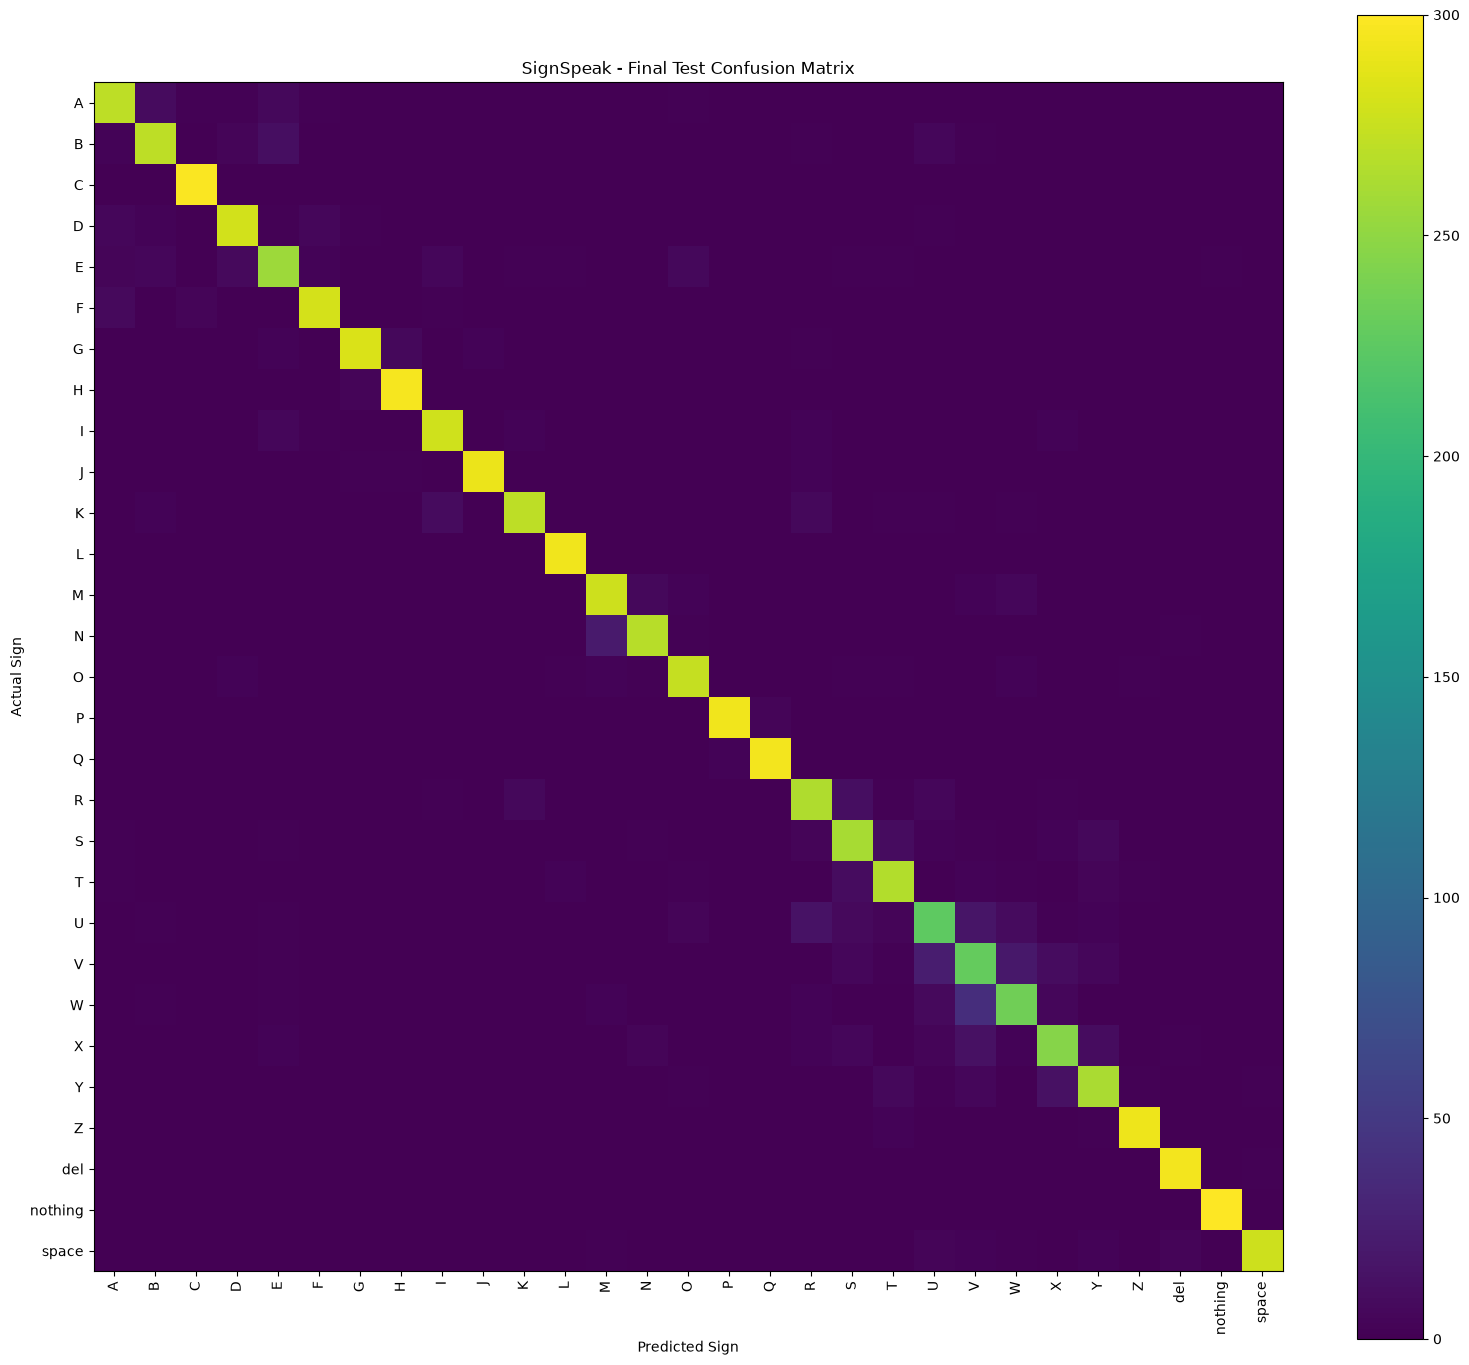

In [32]:
# Visualize final test confusion matrix

fig, ax = plt.subplots(figsize=(16, 14))

im = ax.imshow(test_cm)

ax.set_xticks(
    np.arange(len(label_encoder.classes_))
)

ax.set_yticks(
    np.arange(len(label_encoder.classes_))
)

ax.set_xticklabels(
    label_encoder.classes_,
    rotation=90
)

ax.set_yticklabels(
    label_encoder.classes_
)

ax.set_xlabel("Predicted Sign")
ax.set_ylabel("Actual Sign")

ax.set_title(
    "SignSpeak - Final Test Confusion Matrix"
)

fig.colorbar(im, ax=ax)

plt.tight_layout()
plt.show()

In [33]:
# Find most common test-set prediction mistakes

test_confusions = []

for actual in range(len(label_encoder.classes_)):
    for predicted in range(len(label_encoder.classes_)):

        if actual != predicted and test_cm[actual, predicted] > 0:

            test_confusions.append({
                "Actual": label_encoder.classes_[actual],
                "Predicted": label_encoder.classes_[predicted],
                "Count": test_cm[actual, predicted]
            })

test_confusion_df = pd.DataFrame(test_confusions)

test_confusion_df = test_confusion_df.sort_values(
    "Count",
    ascending=False
).reset_index(drop=True)

print("Top 15 final test prediction mistakes:")

display(test_confusion_df.head(15))

Top 15 final test prediction mistakes:


,Actual,Predicted,Count
0,W,V,39
1,V,U,24
2,N,M,22
3,V,W,19
4,U,V,17
5,U,R,15
6,Y,X,14
7,X,V,13
8,B,E,11
9,R,S,11


In [34]:
# Save final experiment summary

RESULTS_DIR = Path("../results")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

experiment_results = pd.DataFrame([
    {
        "Model": "Linear SVM",
        "Feature Extraction": "HOG",
        "Training Samples": len(y_train),
        "Validation Samples": len(y_val),
        "Test Samples": len(y_test),
        "Classes": len(label_encoder.classes_),
        "Features Per Image": X_train.shape[1],
        "Training Time (s)": round(training_time, 2),
        "Validation Accuracy (%)": round(val_accuracy * 100, 2),
        "Test Accuracy (%)": round(test_accuracy * 100, 2),
        "Correct Test Predictions": int(
            np.sum(y_test_encoded == y_test_pred)
        ),
        "Incorrect Test Predictions": int(
            np.sum(y_test_encoded != y_test_pred)
        )
    },
    {
        "Model": "SGD Classifier",
        "Feature Extraction": "HOG",
        "Training Samples": len(y_train),
        "Validation Samples": len(y_val),
        "Test Samples": "Not used",
        "Classes": len(label_encoder.classes_),
        "Features Per Image": X_train.shape[1],
        "Training Time (s)": round(sgd_training_time, 2),
        "Validation Accuracy (%)": round(sgd_accuracy * 100, 2),
        "Test Accuracy (%)": "Not evaluated",
        "Correct Test Predictions": "-",
        "Incorrect Test Predictions": "-"
    }
])

experiment_results.to_csv(
    RESULTS_DIR / "model_comparison.csv",
    index=False
)

experiment_results

,Model,Feature Extraction,Training Samples,Validation Samples,Test Samples,Classes,Features Per Image,Training Time (s),Validation Accuracy (%),Test Accuracy (%),Correct Test Predictions,Incorrect Test Predictions
0,Linear SVM,HOG,14500,8700,8700,29,8100,431.02,91.14,91.09,7925,775
1,SGD Classifier,HOG,14500,8700,Not used,29,8100,12.64,88.95,Not evaluated,-,-


In [35]:
# Save final test confusion analysis

test_confusion_df.to_csv(
    RESULTS_DIR / "test_confusions.csv",
    index=False
)

test_class_results.to_csv(
    RESULTS_DIR / "test_classification_metrics.csv"
)

print("Experiment results saved successfully ✅")
print("Saved:")
print("- model_comparison.csv")
print("- test_confusions.csv")
print("- test_classification_metrics.csv")

Experiment results saved successfully ✅
Saved:
- model_comparison.csv
- test_confusions.csv
- test_classification_metrics.csv
